# Can a fine-tuned embedder compete with the generative Jev clones?

v1 (Qwen3 0.6B) and v2 (Qwen3 4B) read a decision task and write the letter of the right option.
An embedder solves the same task differently: embed the task, embed every option, and pick the
option whose vector is closest. This notebook trains a Qwen3 **embedding** model on the exact same
39,000 training rows and grades them on the exact same 5,600 eval rows (2,600 dev from trained
tasks, 3,000 held-out from tasks nobody trained on, including app_reviews).

| contender | how it is scored |
|---|---|
| v1, v2 (prompt once / twice) | cached per-row results from `jev_classifier.ipynb` / `jev_classifier_v2.ipynb` |
| Qwen3-Embedding 4B, **fine-tuned** | trained here; scored inside the training session |
| same embedder **before** training | scored in the same session, before the first step |
| Qwen3-Embedding 8B (serverless, zero-shot) | `/v1/embeddings` |
| Qwen3-Reranker 8B (serverless, zero-shot) | `/v1/rerank`: reads task and option together |

**Why scored in-session.** Serving a fine-tuned embedder means downloading its weights and
re-registering them, and this account cannot download models. So we compute embeddings with the
trainer itself (a forward pass with a zero loss and no optimizer step) before the session ends.

**Probabilities and calibration.** Similarity scores are not probabilities. Every contender gets a
single temperature fitted on **dev** (to minimize log loss) and is reported on **held-out**. To keep
it fair, v1 and v2 are shown both raw and with the same dev-fitted temperature.

**Reported results** (held-out accuracy): untrained 8B embedder 0.722 (best of all models on these rows), v2 prompt twice 0.672, untrained 4B embedder 0.706, fine-tuned 4B embedder 0.636 (fine-tuning overfit: dev 0.726 to 0.867, held-out down). The 4B training run took about 7.5 hours; its scores are cached in `jev_runs/embedder/`, so re-running this notebook reuses them instead of retraining.

## 1. Setup

In [ ]:
import json
import math
import os
import random
import sys
import time
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from math import comb
from pathlib import Path

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)
HERE = Path.cwd()
# The embedder trainer uses the Fireworks cookbook's training utilities (github.com/fw-ai/cookbook).
REPO = Path(os.getenv("COOKBOOK_DIR", Path.home() / "cookbook"))
assert (REPO / "training" / "utils").exists(), f"set COOKBOOK_DIR to a cookbook checkout; {REPO} has no training/utils"
sys.path[:0] = [str(HERE), str(REPO)]
import jev_lib

GO = True

# Eval/train rows: must match jev_classifier.ipynb so rows line up with the cached v1/v2 results.
N_TRAIN_PER_TASK, N_DEV_PER_TASK, N_HELDOUT_PER_TASK = 1500, 100, 500
MAX_OPTIONS, NONE_RATE, SEED = 5, 0.15, 0

EMBEDDERS = {
    "emb-4b": dict(base="accounts/pyroworks/models/qwen3-embedding-4b-ft-base",
                   shape="accounts/fireworks/trainingShapes/qwen3-embedding-base-4b/versions/rirygj9x",
                   tokenizer="Qwen/Qwen3-Embedding-4B"),
}
EPOCHS = 2                 # same data exposure as the generative SFT runs
BATCH_QUERIES = 32
LEARNING_RATE = 1e-5
TRAIN_TEMPERATURE = 0.05
LORA_RANK = 0              # full-parameter, like the Airbnb embedding case study
MAX_QUERY_LEN, MAX_OPTION_LEN = 512, 96
EMBED_CHUNK = 256          # datums per forward call when extracting embeddings
INSTRUCTION = "Given a decision task with a state and a question, retrieve the option that correctly answers it"

V1_DIR = HERE / "jev_runs/308a44"
V2_DIR = next(iter(sorted((HERE / "jev_runs").glob("v2-*"))), None)
WORK = HERE / "jev_runs/embedder"
WORK.mkdir(parents=True, exist_ok=True)
H = {"Authorization": f"Bearer {os.environ['FIREWORKS_API_KEY']}", "Content-Type": "application/json"}
print("v1 results:", V1_DIR, "| v2 results:", V2_DIR)

## 2. Rebuild the rows

Same loaders, seed and option construction as the training notebooks, so the eval rows line up
one-to-one with the cached v1/v2 results (checked below). Each option becomes a short text:
its key and description, e.g. `duplicate charge: The customer reports being charged more than once.`

In [2]:
LETTERS = "ABCDE"[:MAX_OPTIONS]
NONE_OPTION = ("none", "None of the listed options matches.")


def make_options(ex, rng, allow_none):
    classes, gold = ex["classes"], ex["gold"]
    if ex.get("fixed_options") or len(classes) == MAX_OPTIONS:
        opts = list(classes)
    else:
        room = MAX_OPTIONS - 1
        if len(classes) <= room:
            keep = list(classes)
        else:
            others = [c for c in classes if c[0] != gold]
            picked = {gold} | {c[0] for c in rng.sample(others, room - 1)}
            keep = [c for c in classes if c[0] in picked]
        if allow_none and rng.random() < NONE_RATE:
            keep = [c for c in keep if c[0] != gold]
            gold = "none"
        opts = keep + [NONE_OPTION]
    keys = [k for k, _ in opts]
    options = [{"label": LETTERS[i], "key": k, "description": d} for i, (k, d) in enumerate(opts)]
    return options, keys.index(gold)


rng = random.Random(SEED)
TRAIN, DEV, HELD = [], [], []
for task in tqdm(jev_lib.TASKS, desc="tasks"):
    n = N_HELDOUT_PER_TASK if task.heldout else N_TRAIN_PER_TASK + N_DEV_PER_TASK
    for i, ex in enumerate(task.load(n, SEED)):
        split = "heldout" if task.heldout else ("dev" if i < N_DEV_PER_TASK else "train")
        options, gold = make_options(ex, rng, allow_none=(split == "train"))
        item = {"task": task.name, "family": task.family, "split": split, "state": ex["state"],
                "question": ex["question"], "options": options, "gold": gold}
        {"train": TRAIN, "dev": DEV, "heldout": HELD}[split].append(item)
random.Random(SEED).shuffle(TRAIN)
EVAL = DEV + HELD


def query_text(it):
    return f"Instruct: {INSTRUCTION}\nQuery:{it['question']}\n{it['state']}"


def option_text(o):
    k = o["key"]
    return o["description"] if k.startswith("choice_") else f"{k.replace('_', ' ')}: {o['description']}"


v1_gold = [json.loads(l)["gold"] for l in open(V1_DIR / "eval_sft_plain.jsonl")]
v1_idx = [json.loads(l)["idx"] for l in open(V1_DIR / "eval_sft_plain.jsonl")]
assert all(EVAL[i]["gold"] == g for i, g in zip(v1_idx, v1_gold)), "rebuilt rows do not match the cached v1 eval"
print(f"train={len(TRAIN):,} dev={len(DEV):,} heldout={len(HELD):,}; rows match the cached v1 eval")
print("example query :", query_text(EVAL[0])[:160].replace("\n", " | "))
print("example option:", option_text(EVAL[0]["options"][0]))

tasks: 100%|██████████| 32/32 [00:14<00:00,  2.22it/s]

train=39,000 dev=2,600 heldout=3,000; rows match the cached v1 eval
example query : Instruct: Given a decision task with a state and a question, retrieve the option that correctly answers it | Query:How does the hypothesis relate to the premise? | 
example option: entailment: The hypothesis follows from the premise.


## 3. Zero-shot baselines on serverless

Cheap reference points before any training: the 8B embedder (cosine similarity between task and
option) and the 8B reranker (reads task and option together, returns a relevance score). About 5,600
requests each; cents.

In [3]:
def post(url, body, retries=6):
    for a in range(retries):
        r = requests.post(url, headers=H, json=body, timeout=120)
        if r.status_code in (429, 500, 502, 503, 504) and a < retries - 1:
            time.sleep(2 ** a); continue
        r.raise_for_status()
        return r.json()


def cached(name, fn):
    path = WORK / f"scores_{name}.json"
    if path.exists():
        return json.loads(path.read_text())
    out = fn()
    path.write_text(json.dumps(out))
    return out


def serverless_embed_scores():
    def one(it):
        texts = [query_text(it)] + [option_text(o) for o in it["options"]]
        v = np.array([d["embedding"] for d in post("https://api.fireworks.ai/inference/v1/embeddings",
                                                   {"model": "fireworks/qwen3-embedding-8b", "input": texts})["data"]])
        v /= np.linalg.norm(v, axis=1, keepdims=True)
        return (v[1:] @ v[0]).tolist()
    with ThreadPoolExecutor(8) as pool:
        return list(tqdm(pool.map(one, EVAL), total=len(EVAL), desc="qwen3-embedding-8b"))


def serverless_rerank_scores():
    def one(it):
        docs = [option_text(o) for o in it["options"]]
        res = post("https://api.fireworks.ai/inference/v1/rerank",
                   {"model": "fireworks/qwen3-reranker-8b", "query": f"{it['question']}\n{it['state']}",
                    "documents": docs, "top_n": len(docs)})["data"]
        s = [0.0] * len(docs)
        for d in res:
            p = min(max(d["relevance_score"], 1e-6), 1 - 1e-6)
            s[d["index"]] = math.log(p / (1 - p))       # relevance probability -> logit
        return s
    with ThreadPoolExecutor(8) as pool:
        return list(tqdm(pool.map(one, EVAL), total=len(EVAL), desc="qwen3-reranker-8b"))


SCORES = {}
if GO:
    SCORES["zs-emb-8b"] = cached("zs-emb-8b", serverless_embed_scores)
    SCORES["zs-rerank-8b"] = cached("zs-rerank-8b", serverless_rerank_scores)
for k, s in SCORES.items():
    print(f"{k}: dev acc {np.mean([np.argmax(x) == it['gold'] for x, it in zip(s, EVAL) if it['split'] == 'dev']):.3f}")

zs-emb-8b: dev acc 0.764
zs-rerank-8b: dev acc 0.775


## 4. Fine-tune the 4B embedder

**Objective.** For each training row, the task embedding should be closer to the correct option than
to the other options listed in that same row (the model sees exactly the choice it will face at
eval time). Loss: cross-entropy over the row's own options, on cosine similarity divided by
`TRAIN_TEMPERATURE`. Options are de-duplicated within a batch, so each batch is
`BATCH_QUERIES` task texts plus the distinct option texts they reference.

**Scoring in-session.** Before the first step and after the last, every eval task and option is
embedded with a forward pass whose loss is zero (so nothing changes), and cosine scores are saved
to disk. Progress bars cover both training steps and embedding extraction.

**Cached.** If `jev_runs/embedder/scores_emb-4b-tuned.json` exists the training is skipped and the cached scores are loaded. Delete that file to retrain (about 7.5 hours).

In [ ]:
import tinker
from tinker import types
from training.utils import DEFAULT_ADAM, ReconnectableClient, TrainerConfig, build_service_client, load_tokenizer
from training.utils.client import DEFAULT_TIMEOUT_S


def datums(tok, texts, max_len):
    ids = tok(texts, add_special_tokens=True, truncation=True, max_length=max_len, padding=False)["input_ids"]
    return [types.Datum(model_input=types.ModelInput.from_ints(list(x)), loss_fn_inputs={}) for x in ids]


def embed_texts(client, tok, texts, max_len, desc):
    # Forward pass with a zero loss: gradients are zero and no optimizer step follows.
    out = []
    for i in tqdm(range(0, len(texts), EMBED_CHUNK), desc=desc, leave=False):
        grabbed = []

        def zero_loss(_data, embeddings):
            grabbed.extend(e.detach().to(torch.float32) for e in embeddings)
            return torch.stack(embeddings).sum() * 0.0, {}

        client.forward_backward_custom(datums(tok, texts[i:i + EMBED_CHUNK], max_len), zero_loss,
                                       output="embedding", pooling="last")
        out.extend(grabbed)
    return F.normalize(torch.stack(out), dim=-1)


def eval_scores(client, tok, label):
    qv = embed_texts(client, tok, [query_text(it) for it in EVAL], MAX_QUERY_LEN, f"{label} tasks")
    uniq = sorted({option_text(o) for it in EVAL for o in it["options"]})
    ov = embed_texts(client, tok, uniq, MAX_OPTION_LEN, f"{label} options")
    pos = {t: i for i, t in enumerate(uniq)}
    return [[float(ov[pos[option_text(o)]] @ qv[j]) for o in it["options"]] for j, it in enumerate(EVAL)]


def listwise_loss_fn(n_q, groups):
    def loss_fn(_data, embeddings):
        z = F.normalize(torch.stack(embeddings).to(torch.float32), dim=-1)
        q, opts = z[:n_q], z[n_q:]
        losses, hits = [], 0
        for j, (idx, gold) in enumerate(groups):
            logits = (opts[idx] @ q[j]) / TRAIN_TEMPERATURE
            losses.append(F.cross_entropy(logits[None], torch.tensor([gold])))
            hits += int(logits.argmax().item() == gold)
        loss = torch.stack(losses).mean()
        return loss, {"loss": float(loss.item()), "acc": hits / n_q}
    return loss_fn


def train_and_score(name, spec):
    if (WORK / f"scores_{name}-tuned.json").exists():
        print(f"{name}: already scored, skipping")
        return
    tok = load_tokenizer(spec["tokenizer"], "")
    steps_total = EPOCHS * (len(TRAIN) // BATCH_QUERIES)
    print(f"{name}: {steps_total:,} steps of {BATCH_QUERIES} tasks")
    try:
        service = build_service_client(
            api_key=os.environ["FIREWORKS_API_KEY"], base_url="https://api.fireworks.ai", additional_headers=None,
            base_model=spec["base"], tokenizer_model=spec["tokenizer"], max_lora_rank=LORA_RANK,
            max_context_length=max(MAX_QUERY_LEN, MAX_OPTION_LEN), learning_rate=LEARNING_RATE,
            trainer=TrainerConfig(training_shape_id=spec["shape"]), cleanup_trainer_on_close=True)
    except Exception as e:  # noqa: BLE001
        print(f"{name}: trainer rejected this base model, skipping it: {str(e)[:300]}")
        return
    try:
        tc = service.create_training_client(spec["base"], lora_rank=LORA_RANK)
        client = ReconnectableClient.from_training_client(tc, base_model=spec["base"], lora_rank=LORA_RANK,
                                                          job_id=service.trainer_job_id, default_timeout=DEFAULT_TIMEOUT_S,
                                                          service=service)
        (WORK / f"scores_{name}-base.json").write_text(json.dumps(eval_scores(client, tok, f"{name} base")))
        print(f"{name}: base scored")

        adam = tinker.AdamParams(learning_rate=LEARNING_RATE, **DEFAULT_ADAM)
        bar = tqdm(total=steps_total, desc=f"{name} train")
        log = open(WORK / f"train_{name}.log", "a")
        for epoch in range(EPOCHS):
            rows = list(TRAIN)
            random.Random(SEED + epoch).shuffle(rows)
            for s in range(0, len(rows) - BATCH_QUERIES + 1, BATCH_QUERIES):
                batch = rows[s:s + BATCH_QUERIES]
                uniq = sorted({option_text(o) for it in batch for o in it["options"]})
                pos = {t: i for i, t in enumerate(uniq)}
                groups = [([pos[option_text(o)] for o in it["options"]], it["gold"]) for it in batch]
                data = datums(tok, [query_text(it) for it in batch], MAX_QUERY_LEN) + datums(tok, uniq, MAX_OPTION_LEN)
                res = client.forward_backward_custom(data, listwise_loss_fn(len(batch), groups),
                                                     output="embedding", pooling="last")
                client.optim_step(adam)
                m = dict(res.metrics)
                bar.update(1); bar.set_postfix(loss=f"{m.get('loss', m.get('loss:sum', float('nan'))):.3f}", acc=f"{m.get('acc', 0):.2f}")
                log.write(json.dumps({"epoch": epoch, "step": bar.n, **m}) + "\n"); log.flush()
        bar.close()
        (WORK / f"scores_{name}-tuned.json").write_text(json.dumps(eval_scores(client, tok, f"{name} tuned")))
        print(f"{name}: tuned scored")
    finally:
        service.close()


if GO:
    for name, spec in EMBEDDERS.items():
        train_and_score(name, spec)
for f in sorted(WORK.glob("scores_emb-*.json")):
    SCORES[f.stem.replace("scores_", "")] = json.loads(f.read_text())
print("embedder score sets:", sorted(k for k in SCORES if k.startswith("emb")))

## 5. Put everyone on the same footing

Every contender becomes a list of per-option scores per eval row. For v1/v2 those are the
log-probabilities they already produced. One temperature per contender is fitted on **dev** to
minimize log loss; held-out is never used for fitting.

In [ ]:
for f in sorted(WORK.glob("scores_emb-*.json")):
    SCORES[f.stem.replace("scores_", "")] = json.loads(f.read_text())
print(sorted(k for k in SCORES if k.startswith("emb")))

['emb-4b-base', 'emb-4b-tuned']


In [ ]:
def load_llm(path):
    rows = {r["idx"]: r for r in map(json.loads, open(path))}
    out = []
    for i, it in enumerate(EVAL):
        p = rows[i].get("probs")
        out.append([math.log(max(x, 1e-9)) for x in p] if p else [0.0] * len(it["options"]))
    return out


RAW_PROBS = {}
for tag, d in (("v1", V1_DIR), ("v2", V2_DIR)):
    for style in ("plain", "repeat"):
        f = d / f"eval_sft_{style}.jsonl" if d else None
        if f and f.exists():
            SCORES[f"{tag}-{style}"] = load_llm(f)
            RAW_PROBS[f"{tag}-{style}"] = True


def probs(scores, T):
    s = np.array(scores) / T
    s = np.exp(s - s.max())
    return s / s.sum()


def fit_T(scores):
    dev = [(s, it["gold"]) for s, it in zip(scores, EVAL) if it["split"] == "dev"]
    grid = np.exp(np.linspace(np.log(0.005), np.log(20), 200))
    nll = [np.mean([-math.log(max(probs(s, T)[g], 1e-12)) for s, g in dev]) for T in grid]
    return float(grid[int(np.argmin(nll))])


TEMPS = {k: fit_T(s) for k, s in SCORES.items()}
print({k: round(v, 4) for k, v in TEMPS.items()})

{'zs-emb-8b': 0.0402, 'zs-rerank-8b': 1.0814, 'v1-plain': 1.5093, 'v1-repeat': 1.4477, 'v2-plain': 1.6405, 'v2-repeat': 1.5736, 'emb-4b-base': 0.0475, 'emb-4b-tuned': 0.0816}


## 6. Results

In [ ]:
def rows_for(name, T):
    out = []
    for s, it in zip(SCORES[name], EVAL):
        p = probs(s, T)
        out.append({"task": it["task"], "split": it["split"], "gold": it["gold"], "pred": int(p.argmax()),
                    "conf": float(p.max()), "correct": int(p.argmax() == it["gold"]), "p": p})
    return out


def ece(rows, bins=15):
    conf = np.array([r["conf"] for r in rows]); corr = np.array([r["correct"] for r in rows])
    idx = np.clip(np.digitize(conf, np.linspace(0, 1, bins + 1)[1:-1]), 0, bins - 1)
    return float(sum(abs(corr[idx == b].mean() - conf[idx == b].mean()) * (idx == b).mean() for b in range(bins) if (idx == b).any()))


VIEWS = {}
for k in SCORES:
    VIEWS[f"{k} (T={TEMPS[k]:.3g})"] = rows_for(k, TEMPS[k])
    if k in RAW_PROBS:
        VIEWS[f"{k} (raw)"] = rows_for(k, 1.0)

tab = []
for name, rows in VIEWS.items():
    for split in ("dev", "heldout"):
        r = [x for x in rows if x["split"] == split]
        tab.append({"model": name, "slice": split, "accuracy": np.mean([x["correct"] for x in r]), "ece": ece(r),
                    "brier": np.mean([sum((pp - (i == x["gold"])) ** 2 for i, pp in enumerate(x["p"])) for x in r])})
RES = pd.DataFrame(tab).pivot(index="model", columns="slice", values=["accuracy", "ece", "brier"])
display(RES.sort_values(("accuracy", "heldout"), ascending=False).round(3))
RES.to_csv(WORK / "results.csv")

HT = sorted({it["task"] for it in HELD})
per = pd.DataFrame({name: {t: np.mean([x["correct"] for x in rows if x["task"] == t]) for t in HT} for name, rows in VIEWS.items()
                    if "(raw)" not in name})
display(per.round(3))

accuracy            ece          brier        
slice                        dev heldout    dev heldout    dev heldout
model                                                                 
zs-emb-8b (T=0.0402)       0.764   0.722  0.039   0.101  0.324   0.388
emb-4b-base (T=0.0475)     0.726   0.706  0.038   0.073  0.363   0.430
v2-repeat (T=1.57)         0.887   0.672  0.019   0.065  0.171   0.445
v2-repeat (raw)            0.887   0.672  0.056   0.154  0.180   0.480
v2-plain (T=1.64)          0.881   0.665  0.020   0.081  0.174   0.448
v2-plain (raw)             0.881   0.665  0.056   0.169  0.183   0.490
emb-4b-tuned (T=0.0816)    0.867   0.636  0.025   0.106  0.206   0.513
zs-rerank-8b (T=1.08)      0.775   0.628  0.024   0.087  0.307   0.483
v1-repeat (T=1.45)         0.845   0.626  0.016   0.073  0.214   0.476
v1-repeat (raw)            0.845   0.626  0.045   0.145  0.220   0.505
v1-plain (T=1.51)          0.837   0.608  0.018   0.053  0.220   0.498
v1-plain (raw)             0.837   0.608  0.057   0.129  0.229   0.524

,zs-emb-8b (T=0.0402),zs-rerank-8b (T=1.08),v1-plain (T=1.51),v1-repeat (T=1.45),v2-plain (T=1.64),v2-repeat (T=1.57),emb-4b-base (T=0.0475),emb-4b-tuned (T=0.0816)
app_reviews_binary,0.844,0.808,0.816,0.808,0.842,0.832,0.876,0.842
app_reviews_sent3,0.768,0.768,0.764,0.748,0.772,0.774,0.794,0.768
app_reviews_stars5,0.720,0.376,0.412,0.538,0.600,0.576,0.704,0.592
emotion,0.762,0.702,0.632,0.646,0.646,0.684,0.724,0.600
tweet_irony,0.550,0.500,0.532,0.522,0.570,0.552,0.498,0.526
yelp_stars5,0.690,0.616,0.492,0.494,0.558,0.616,0.642,0.490


### Is the difference real?

Paired on identical rows (correctness does not depend on temperature). "fixed" = rows the second
model got right that the first got wrong. p below 0.05 means a real difference; otherwise a tie.

In [ ]:
def mcnemar(a, b):
    fixed = sum(1 for x, y in zip(a, b) if not x["correct"] and y["correct"])
    broke = sum(1 for x, y in zip(a, b) if x["correct"] and not y["correct"])
    n, k = fixed + broke, min(fixed, broke)
    return fixed, broke, (min(1.0, 2 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n) if n else 1.0)


base_of = {k: rows_for(k, TEMPS[k]) for k in SCORES}
pairs = [(a, b) for a, b in [("v2-repeat", "emb-4b-tuned"), ("v2-plain", "emb-4b-tuned"), ("v1-repeat", "emb-4b-tuned"),
                             ("emb-4b-base", "emb-4b-tuned"), ("zs-rerank-8b", "emb-4b-tuned"),
                             ("zs-emb-8b", "emb-4b-tuned")] if a in base_of and b in base_of]
sig = []
for a, b in pairs:
    for split in ("dev", "heldout"):
        ra = [x for x in base_of[a] if x["split"] == split]; rb = [x for x in base_of[b] if x["split"] == split]
        fixed, broke, p = mcnemar(ra, rb)
        sig.append({"from": a, "to": b, "slice": split, "acc_from": np.mean([x["correct"] for x in ra]),
                    "acc_to": np.mean([x["correct"] for x in rb]), "fixed": fixed, "broke": broke, "p": p,
                    "verdict": "real" if p < 0.05 else "tie"})
display(pd.DataFrame(sig).round(4))

,from,to,slice,acc_from,acc_to,fixed,broke,p,verdict
0,v2-repeat,emb-4b-tuned,dev,0.8869,0.8673,101,152,0.0016,real
1,v2-repeat,emb-4b-tuned,heldout,0.6723,0.6363,170,278,0.0000,real
2,v2-plain,emb-4b-tuned,dev,0.8808,0.8673,102,137,0.0276,real
3,v2-plain,emb-4b-tuned,heldout,0.6647,0.6363,163,248,0.0000,real
4,v1-repeat,emb-4b-tuned,dev,0.8454,0.8673,196,139,0.0022,real
5,v1-repeat,emb-4b-tuned,heldout,0.6260,0.6363,272,241,0.1853,tie
6,emb-4b-base,emb-4b-tuned,dev,0.7262,0.8673,518,151,0.0000,real
7,emb-4b-base,emb-4b-tuned,heldout,0.7063,0.6363,175,385,0.0000,real
8,zs-rerank-8b,emb-4b-tuned,dev,0.7746,0.8673,408,167,0.0000,real
9,zs-rerank-8b,emb-4b-tuned,heldout,0.6283,0.6363,353,329,0.3785,tie


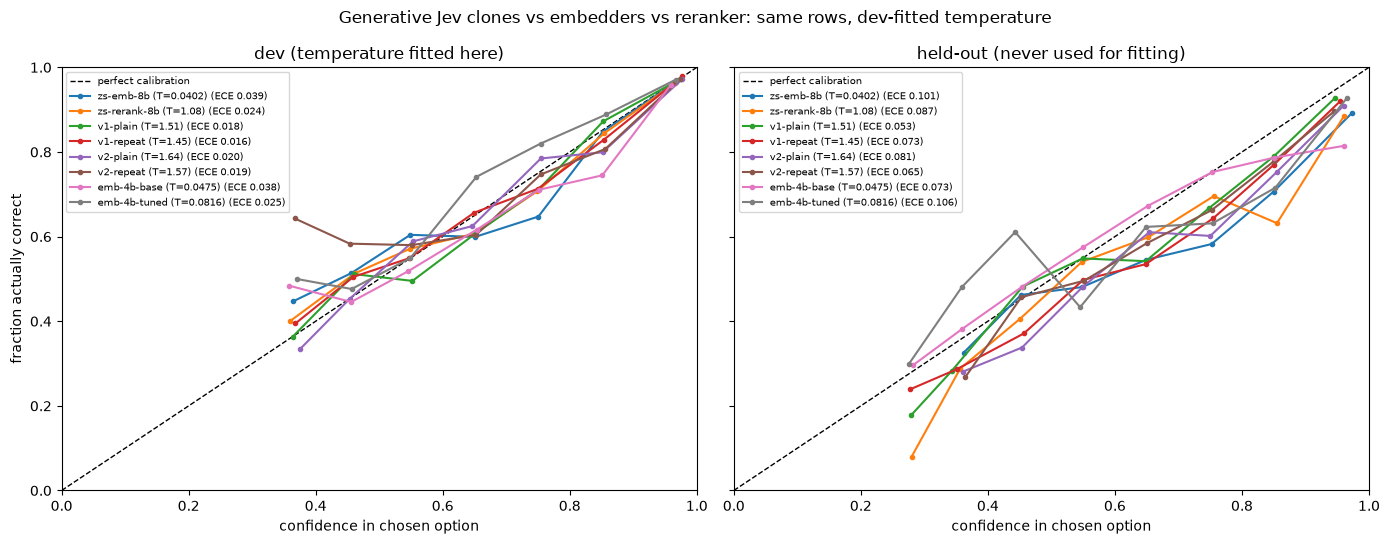

Best held-out accuracy: zs-emb-8b (T=0.0402) (0.722). Check the paired table before calling a winner.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
show = [k for k in VIEWS if "(raw)" not in k]
for ax, split in zip(axes, ("dev", "heldout")):
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
    for name in show:
        r = [x for x in VIEWS[name] if x["split"] == split]
        conf = np.array([x["conf"] for x in r]); corr = np.array([x["correct"] for x in r])
        idx = np.clip(np.digitize(conf, np.linspace(0, 1, 11)[1:-1]), 0, 9)
        pts = [(conf[idx == b].mean(), corr[idx == b].mean()) for b in range(10) if (idx == b).sum() >= 10]
        ax.plot(*zip(*pts), "-o", ms=3, label=f"{name} (ECE {ece(r):.3f})")
    ax.set_title("dev (temperature fitted here)" if split == "dev" else "held-out (never used for fitting)")
    ax.set_xlabel("confidence in chosen option"); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=7)
axes[0].set_ylabel("fraction actually correct")
fig.suptitle("Generative Jev clones vs embedders vs reranker: same rows, dev-fitted temperature")
plt.tight_layout(); plt.savefig(WORK / "reliability.png", dpi=150); plt.show()

h = RES[("accuracy", "heldout")]
print(f"Best held-out accuracy: {h.idxmax()} ({h.max():.3f}). Check the paired table before calling a winner.")